# PatchCore — Multi-Layer Feature Extraction from Raw Images
## MGCLS Anomaly Detection · University of the Western Cape · 2026

This notebook implements **true PatchCore** (Roth et al., CVPR 2022 — arXiv:2106.08265)
on the MGCLS radio-source dataset using raw `.png` images.

### What is different from previous work

Every previous method (Moment Pooling, ECOD, COPOD, DeepSVDD) used the **final
BYOL embedding** — a single 512-dim vector that summarises the whole image.
All spatial information about local morphology has been compressed away by that point.

PatchCore goes back to the raw images and extracts features from **two intermediate
layers** of a pretrained CNN (WideResNet50). Earlier layers keep fine local detail
(edges, texture, unusual structure); later layers keep higher-level semantics.
Combining both gives a richer, multi-scale representation.

### Pipeline overview

```
Raw .png images
      ↓
WideResNet50 pretrained on ImageNet  (FROZEN — no training)
      ├─ Layer 2 → (256-dim) local structure
      └─ Layer 3 → (512-dim) semantic content
      ↓
L2-normalise each layer → concatenate → 768-dim per image
      ↓
Whiten (StandardScaler)
      ↓
Memory bank (all feature vectors stored)
      ↓
k-NN anomaly score: distance to k nearest neighbours
      ↓
Evaluate: ROC-AUC, PR-AUC, Recall@100, Spearman
      ↓
Compare against Protege baseline
```


## 1. Install Dependencies

In [1]:
import sys
!{sys.executable} -m pip install torch torchvision --quiet
!{sys.executable} -m pip install Pillow --quiet
print("Done.")


You should consider upgrading via the '/Users/xm/Documents/Internship/Project/PatchCore/.venv/bin/python -m pip install --upgrade pip' command.
You should consider upgrading via the '/Users/xm/Documents/Internship/Project/PatchCore/.venv/bin/python -m pip install --upgrade pip' command.
Done.


## 2. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             pairwise_distances_chunked)

from utils import load_features, load_catalogue, compute_metrics, BASE_DIR

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'PyTorch: {torch.__version__}')


Device : cpu
PyTorch: 2.2.2


## 3. Helper Functions

In [3]:
# ── Evaluation helpers (same as main notebook) ───────────────────────────────

def compute_ind_sum(found_inds, all_inds):
    this_found_inds = sorted(found_inds)
    out = np.zeros(len(all_inds))
    for i in this_found_inds:
        out[i:] += 1
    return out


def cumulative_sum(anomaly_scores, labels):
    """Running count of true anomalies as we walk down the ranked list."""
    sorted_inds = anomaly_scores.sort_values(ascending=False).index
    labs        = labels.loc[anomaly_scores.index]
    anom_inds   = labs[labs == 1].index
    found_inds  = []
    for i in anom_inds:
        pos = np.where(sorted_inds == i)[0]
        if len(pos) > 0:
            found_inds.append(pos[0])
    return compute_ind_sum(found_inds, sorted_inds)


def topk_recall(y_true, scores, k=100):
    """Fraction of true anomalies found in the top-k ranked candidates."""
    ranked = scores.sort_values(ascending=False).index[:k]
    return y_true.loc[ranked].sum() / y_true.sum()


def evaluate(name, scores, y_true, labels_raw):
    """Return one result row in the standard format."""
    m = compute_metrics(y_true, scores)
    return {
        'Method':           name,
        'ROC-AUC (4-5)':    round(m['roc_auc'], 4),
        'PR-AUC (4-5)':     round(m['pr_auc'],  4),
        'Recall@100 (4-5)': round(topk_recall(y_true, scores), 4),
        'Spearman (1-5)':   round(labels_raw.corr(scores, method='spearman'), 4),
    }


def show_results(methods_dict, y_true, labels_raw):
    """Standard evaluation table sorted by ROC-AUC."""
    rows = [evaluate(n, s, y_true, labels_raw)
            for n, s in methods_dict.items()]
    df = pd.DataFrame(rows).set_index('Method')
    display(df.sort_values('ROC-AUC (4-5)', ascending=False))
    return df


def discovery_plot(methods_dict, y_true, highlight=None):
    """Standard cumulative discovery curve."""
    colors     = ['#1f77b4','#d62728','#2ca02c','#ff7f0e','#8c564b',
                  '#e377c2','#17becf','#9467bd','#bcbd22','#e74c3c']
    linestyles = ['-','--','-.', ':','-','-.','--',':','-.','--']

    fig, ax = plt.subplots(figsize=(8, 5))
    for (name, scores), c, ls in zip(methods_dict.items(), colors, linestyles):
        lw  = 2.4 if (highlight and name in highlight) else 1.3
        cum = cumulative_sum(scores, y_true)
        ax.plot(cum, label=name, color=c, linestyle=ls, linewidth=lw)
    ax.set_xlabel('Rank (ordered by anomaly score)')
    ax.set_ylabel('Anomalies found (score ≥ 4)')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


## 4. Load Catalogue and Baseline

In [4]:
# Load catalogue and BYOL features (needed for objid alignment and baseline)
X_byol = load_features()
cat    = load_catalogue()

X_byol = X_byol.loc[cat.objid]

labels        = cat.set_index('objid')['evaluation_subset_author_ML_score'].loc[X_byol.index]
y_interesting = (labels >= 4).astype(int)

# Protege baseline score — our gold standard comparison
pca_scores = cat.set_index('objid')['protege_score'].loc[X_byol.index]
pca_scores.name = 'score'

print(f'Dataset  : {X_byol.shape[0]} objects')
print(f'Anomalies: {y_interesting.sum()} / {len(y_interesting)} (score ≥ 4)')
print(f'Prevalence: {y_interesting.mean():.2%}')


Features loaded: (6332, 1280)
Catalogue loaded: (6161, 12)
Dataset  : 6161 objects
Anomalies: 86 / 6161 (score ≥ 4)
Prevalence: 1.40%


## 5. Discover Images

Images are stored in two folders under `data/images/`.
We build an `objid → file path` mapping, then check alignment with the catalogue.


In [5]:
IMAGE_DIRS = [
    BASE_DIR / 'data' / 'images' / 'all_images_compressed_part1',
    BASE_DIR / 'data' / 'images' / 'all_images_compressed_part2',
]

# ── Key fact (from the README) ────────────────────────────────────────────────
# The .png filenames are the PROTEGE RANK of each object.
# 0.png = the object Protege ranked #0 (highest anomaly score)
# 1.png = rank #1, and so on.
# The catalogue has a 'protege_rank' column that holds these integers.

# Build integer protege_rank → Path mapping
image_map_int = {}
for d in IMAGE_DIRS:
    if not d.exists():
        print(f'WARNING: {d} not found')
        continue
    for p in d.glob('*.png'):
        image_map_int[int(p.stem)] = p

print(f'Total images found       : {len(image_map_int)}')
print(f'Protege rank range       : {min(image_map_int)} – {max(image_map_int)}')

# Build objid → Path using protege_rank column
image_map = {}
for _, row in cat.iterrows():
    rank  = int(row['protege_rank'])
    objid = row['objid']
    if rank in image_map_int:
        image_map[objid] = image_map_int[rank]

print(f'Mapped objids → images   : {len(image_map)}')

# Align with X_byol index
objids_all     = list(X_byol.index)
objids_found   = [oid for oid in objids_all if oid in image_map]
objids_missing = [oid for oid in objids_all if oid not in image_map]

print(f'Objects in catalogue     : {len(objids_all)}')
print(f'Objects with images      : {len(objids_found)}')
print(f'Objects missing images   : {len(objids_missing)}')

if objids_missing:
    print(f'  First 3 missing objids : {objids_missing[:3]}')


Total images found       : 6161
Protege rank range       : 0 – 6160
Mapped objids → images   : 6161
Objects in catalogue     : 6161
Objects with images      : 6161
Objects missing images   : 0


### Preview Sample Images

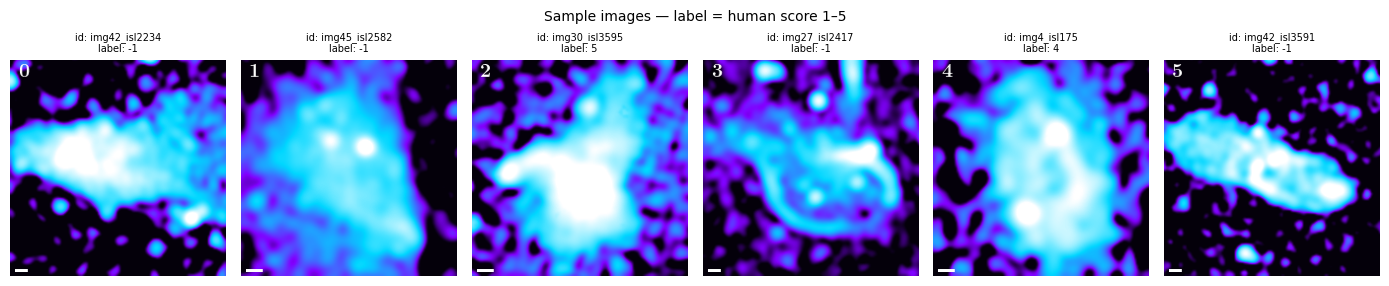

In [7]:
sample_ids = objids_found[:6]

fig, axes = plt.subplots(1, len(sample_ids), figsize=(14, 3))
for ax, oid in zip(axes, sample_ids):
    img = Image.open(image_map[oid]).convert('RGB')
    lbl = labels.loc[oid] if oid in labels.index else '?'
    ax.imshow(img)
    ax.set_title(f'id: {oid}\nlabel: {lbl}', fontsize=7)
    ax.axis('off')
plt.suptitle('Sample images — label = human score 1–5', fontsize=10)
plt.tight_layout()
plt.show()


## 6. Multi-Layer Feature Extractor

We use **WideResNet50_2** pretrained on ImageNet as a frozen feature extractor.

### Why WideResNet50?
- Standard backbone used in the original PatchCore paper
- Pretrained on ImageNet — strong general visual features
- Wide architecture (2× channels) captures more detail than standard ResNet50

### Why these two layers?

| Layer | Output channels | What it captures |
|---|---|---|
| `layer2` | 256 | Local texture, edges, spatial patterns, unusual morphology |
| `layer3` | 512 | Higher-level semantic content, global structure |

Each layer's spatial feature map is collapsed to one vector per image using
**global average pooling**, then **L2-normalised** independently.
Final concatenated vector: 256 + 512 = **768 dimensions per image**.

The network weights are **never updated** — we only do a forward pass.


In [8]:
class PatchCoreExtractor:
    """
    Extracts 768-dim multi-layer features from images using frozen WideResNet50.

    Architecture:
        image (3×224×224)
            ↓  WideResNet50 (frozen)
            ├─ layer2 → pool → L2-norm → 256-dim
            └─ layer3 → pool → L2-norm → 512-dim
            ↓  concatenate
        feature vector (768-dim)

    No training — only inference (one forward pass per image).
    """

    def __init__(self, device):
        self.device = device

        # Load WideResNet50 pretrained on ImageNet
        backbone = models.wide_resnet50_2(
            weights=models.Wide_ResNet50_2_Weights.IMAGENET1K_V1
        )
        backbone.eval()
        for p in backbone.parameters():
            p.requires_grad = False     # freeze all weights

        # Sub-network up to layer2 (local features, 256 channels)
        self.layer2_net = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2
        ).to(device)

        # Sub-network up to layer3 (semantic features, 512 channels)
        self.layer3_net = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3
        ).to(device)

        # Global average pool: (C, H, W) → (C,)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # ImageNet normalisation — required for pretrained weights
        self.transform = T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            # Radio images are single-channel — replicate to 3 channels
            T.Lambda(lambda x: x.repeat(3, 1, 1) if x.shape[0] == 1 else x),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std =[0.229, 0.224, 0.225]),
        ])

    def extract_batch(self, image_paths: list) -> np.ndarray:
        """
        Extract 768-dim features for a list of image file paths.
        Returns np.ndarray of shape (N, 768).
        """
        tensors = []
        for p in image_paths:
            try:
                img = Image.open(p).convert('RGB')
                tensors.append(self.transform(img))
            except Exception as e:
                print(f'  WARNING: could not load {p}: {e}')
                tensors.append(torch.zeros(3, 224, 224))

        batch = torch.stack(tensors).to(self.device)

        with torch.no_grad():
            # (N, 256, H2, W2) → pool → (N, 256)
            f2 = self.pool(self.layer2_net(batch)).squeeze(-1).squeeze(-1)
            # (N, 512, H3, W3) → pool → (N, 512)
            f3 = self.pool(self.layer3_net(batch)).squeeze(-1).squeeze(-1)

        f2 = f2.cpu().numpy()
        f3 = f3.cpu().numpy()

        # L2-normalise each layer independently
        f2_norm = normalize(f2, norm='l2')   # (N, 256)
        f3_norm = normalize(f3, norm='l2')   # (N, 512)

        return np.concatenate([f2_norm, f3_norm], axis=1)   # (N, 768)


extractor = PatchCoreExtractor(device)
print('Extractor ready.')
print('Output: 256 (layer2) + 512 (layer3) = 768 dims per image')


Extractor ready.
Output: 256 (layer2) + 512 (layer3) = 768 dims per image


## 7. Extract Features for All Images

Process every image in batches and save to disk.
The result is a parquet file saved to `data/patchcore_features.parquet`.

**Caching:** if the file already exists, it is loaded directly —
you never need to re-run the extraction.


In [10]:
BATCH_SIZE   = 32
SAVE_PATH    = BASE_DIR / 'data' / 'patchcore_features.parquet'

if SAVE_PATH.exists():
    print(f'Cached features found — loading from {SAVE_PATH}')
    df_pc_features = pd.read_parquet(SAVE_PATH)
    print(f'Loaded: {df_pc_features.shape}  (objects × feature dims)')

else:
    print(f'Extracting features for {len(objids_found)} images...')
    print(f'Batch size : {BATCH_SIZE}')
    print(f'Save path  : {SAVE_PATH}')
    print()

    all_feats  = []
    all_objids = []

    for start in range(0, len(objids_found), BATCH_SIZE):
        batch_ids   = objids_found[start : start + BATCH_SIZE]
        batch_paths = [image_map[oid] for oid in batch_ids]

        feats = extractor.extract_batch(batch_paths)   # (B, 768)
        all_feats.append(feats)
        all_objids.extend(batch_ids)   # keep as strings — objid is 'img42_isl2234'

        n_done = min(start + BATCH_SIZE, len(objids_found))
        print(f'  {n_done:4d} / {len(objids_found)} images processed', end='\r')

    print()
    arr = np.vstack(all_feats)
    df_pc_features = pd.DataFrame(arr, index=all_objids)
    df_pc_features.index.name = 'objid'

    df_pc_features.to_parquet(SAVE_PATH)
    print(f'\nSaved to {SAVE_PATH}')
    print(f'Feature matrix: {df_pc_features.shape}')


Extracting features for 6161 images...
Batch size : 32
Save path  : /Users/xm/Documents/Internship/Project/PatchCore/data/patchcore_features.parquet

  6161 / 6161 images processed

Saved to /Users/xm/Documents/Internship/Project/PatchCore/data/patchcore_features.parquet
Feature matrix: (6161, 1536)


## 8. Align with Evaluation Set

Some catalogue objects may not have images.
We restrict the evaluation to the intersection — objects with both
a catalogue label and an extracted PatchCore feature vector.


In [11]:
# Intersection of catalogue objects and objects with extracted features
eval_ids = [oid for oid in X_byol.index if oid in df_pc_features.index]

X_pc          = df_pc_features.loc[eval_ids]    # PatchCore features
y_pc          = y_interesting.loc[eval_ids]     # binary labels
labels_pc     = labels.loc[eval_ids]            # raw 1-5 labels
pca_scores_pc = pca_scores.loc[eval_ids]        # Protege baseline (same subset)

excluded = len(X_byol.index) - len(eval_ids)

print(f'Catalogue objects     : {len(X_byol.index)}')
print(f'Objects with images   : {len(eval_ids)}')
print(f'Excluded (no image)   : {excluded}')
print(f'Interesting (≥ 4)     : {y_pc.sum()} / {len(y_pc)}')
print(f'Feature dimensions    : {X_pc.shape[1]}')


Catalogue objects     : 6161
Objects with images   : 6161
Excluded (no image)   : 0
Interesting (≥ 4)     : 86 / 6161
Feature dimensions    : 1536


## 9. Whiten the Features

The 512-dim layer3 block contributes 512 dimensions to every Euclidean distance,
while layer2 contributes only 256. Without whitening, layer3 would dominate
every distance calculation simply because it has more dimensions.

`StandardScaler` sets the mean and variance of every dimension to 0 and 1.
After whitening, both layers contribute equally to nearest-neighbour distances.


In [12]:
whitener      = StandardScaler()
X_pc_whitened = whitener.fit_transform(X_pc.values)

print(f'Input shape  : {X_pc.shape}')
print(f'After whiten : {X_pc_whitened.shape}')
print(f'Mean (first 5 dims): {X_pc_whitened[:, :5].mean(axis=0).round(4)}  (should be ~0)')
print(f'Std  (first 5 dims): {X_pc_whitened[:, :5].std(axis=0).round(4)}   (should be ~1)')


Input shape  : (6161, 1536)
After whiten : (6161, 1536)
Mean (first 5 dims): [ 0. -0.  0.  0. -0.]  (should be ~0)
Std  (first 5 dims): [1. 1. 1. 1. 1.]   (should be ~1)


## 10. Build the Memory Bank

The memory bank stores all feature vectors.
At scoring time, each object's anomaly score is its distance to its
nearest neighbour in the bank — objects unlike anything in the bank are anomalous.

For datasets larger than ~10,000 objects, reduce `subsample_ratio`
(e.g. 0.1) to use greedy coreset subsampling instead of keeping all points.


In [13]:
def build_memory_bank(features: np.ndarray,
                      subsample_ratio: float = 1.0,
                      random_state: int = 42) -> np.ndarray:
    """
    Build PatchCore memory bank.

    subsample_ratio=1.0 keeps all points (fine for small datasets).
    For large datasets, greedy coreset subsampling selects a maximally
    spread-out subset: each new point is the one furthest from all
    already-selected points.
    """
    N = len(features)
    n_select = max(1, int(N * subsample_ratio))

    if n_select >= N:
        print(f'Memory bank: keeping all {N} points')
        return features.copy()

    rng      = np.random.default_rng(random_state)
    selected = [int(rng.integers(N))]
    min_dist = np.full(N, np.inf)

    for step in range(1, n_select):
        last     = features[selected[-1]:selected[-1]+1]
        dists    = np.linalg.norm(features - last, axis=1)
        min_dist = np.minimum(min_dist, dists)
        selected.append(int(np.argmax(min_dist)))
        if (step + 1) % 200 == 0 or step == n_select - 1:
            print(f'  Coreset: {step+1}/{n_select}', end='\r')

    print()
    print(f'Memory bank: {len(selected)} / {N} points ({len(selected)/N:.1%})')
    return features[np.array(selected)]


memory_bank = build_memory_bank(X_pc_whitened, subsample_ratio=1.0)
print(f'Memory bank shape: {memory_bank.shape}')


Memory bank: keeping all 6161 points
Memory bank shape: (6161, 1536)


## 11. Anomaly Scoring — k Nearest Neighbours

Each object's anomaly score = mean distance to its k nearest neighbours
in the memory bank.

- **Small distance** → object looks like its neighbours → normal
- **Large distance** → object is unlike anything in the bank → anomalous

We use chunked computation to avoid loading the full N×M distance matrix
into memory at once. k=3 is the default (robust to a single noisy neighbour).


In [14]:
def knn_scores(query: np.ndarray,
               memory: np.ndarray,
               k: int = 3) -> np.ndarray:
    """
    Mean distance to k nearest neighbours in memory bank.
    Uses chunked computation to keep memory usage low.
    """
    N      = len(query)
    scores = np.empty(N)
    done   = 0

    for chunk_dists in pairwise_distances_chunked(
            query, memory, metric='euclidean',
            n_jobs=-1, working_memory=256):
        n_chunk  = chunk_dists.shape[0]
        k_actual = min(k, chunk_dists.shape[1])
        topk     = np.partition(chunk_dists, k_actual - 1, axis=1)[:, :k_actual]
        scores[done : done + n_chunk] = topk.mean(axis=1)
        done += n_chunk
        print(f'  Scoring: {done}/{N}', end='\r')

    print()
    return scores


# ── k sweep: find best k ──────────────────────────────────────────────────────
print('k-NN sweep (k = 1, 3, 5, 10)...')
k_results = {}
k_scores  = {}

for k in [1, 3, 5, 10]:
    raw = knn_scores(X_pc_whitened, memory_bank, k=k)
    s   = pd.Series(raw, index=eval_ids, name='score')
    k_scores[k] = s
    m   = compute_metrics(y_pc, s)
    k_results[k] = m
    print(f'  k={k:2d}  ROC-AUC={m["roc_auc"]:.4f}  '
          f'PR-AUC={m["pr_auc"]:.4f}  '
          f'Recall@100={topk_recall(y_pc, s):.4f}')

best_k = max(k_results, key=lambda k: k_results[k]['roc_auc'])
patchcore_scores = k_scores[best_k]
print(f'\nBest k = {best_k}  →  used for all further evaluation')


k-NN sweep (k = 1, 3, 5, 10)...
  Scoring: 6161/6161
  k= 1  ROC-AUC=0.5582  PR-AUC=0.0238  Recall@100=0.0581
  Scoring: 6161/6161
  k= 3  ROC-AUC=0.8239  PR-AUC=0.0480  Recall@100=0.0465
  Scoring: 6161/6161
  k= 5  ROC-AUC=0.8257  PR-AUC=0.0476  Recall@100=0.0465
  Scoring: 6161/6161
  k=10  ROC-AUC=0.8256  PR-AUC=0.0490  Recall@100=0.0349

Best k = 5  →  used for all further evaluation


## 12. Evaluation

Standard 4-metric table and cumulative discovery curve,
restricted to objects that have both a catalogue label and an extracted image feature.


In [15]:
methods = {
    'PCA (Protege)':   pca_scores_pc,
    f'PatchCore (k={best_k})': patchcore_scores,
}

df_eval = show_results(methods, y_pc, labels_pc)


,ROC-AUC (4-5),PR-AUC (4-5),Recall@100 (4-5),Spearman (1-5)
Method,,,,
PCA (Protege),0.8674,0.1052,0.1744,0.0174
PatchCore (k=5),0.8257,0.0476,0.0465,0.0066


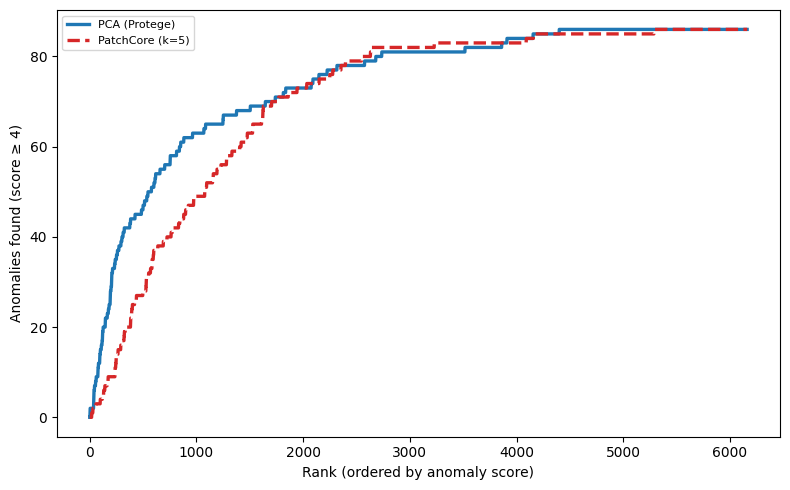

In [16]:
discovery_plot(
    methods,
    y_pc,
    highlight=['PCA (Protege)', f'PatchCore (k={best_k})']
)


## 13. Ablation: Layer 2 vs Layer 3 vs Combined

Test each layer individually to confirm that combining both layers
helps more than using either alone.

| Variant | Features used | Dimensions |
|---|---|---|
| Layer 2 only | Local structure | 256 |
| Layer 3 only | Semantic content | 512 |
| Combined (PatchCore) | Both | 768 |


In [17]:
def ablation_scores(features_whitened: np.ndarray,
                    dims: tuple,
                    index,
                    k: int = 3) -> pd.Series:
    """Score objects using only a slice of the whitened feature vector."""
    subset = features_whitened[:, dims[0]:dims[1]]
    bank   = subset.copy()
    raw    = knn_scores(subset, bank, k=k)
    return pd.Series(raw, index=index, name='score')


print(f'Running ablation (k={best_k})...')

# Layer 2: dims 0–256
print('  Layer 2 only...')
s_l2 = ablation_scores(X_pc_whitened, (0, 256), eval_ids, k=best_k)

# Layer 3: dims 256–768
print('  Layer 3 only...')
s_l3 = ablation_scores(X_pc_whitened, (256, 768), eval_ids, k=best_k)

ablation_methods = {
    'PCA (Protege)':            pca_scores_pc,
    'PatchCore layer2 only':    s_l2,
    'PatchCore layer3 only':    s_l3,
    f'PatchCore combined (k={best_k})': patchcore_scores,
}

df_ablation = show_results(ablation_methods, y_pc, labels_pc)


Running ablation (k=5)...
  Layer 2 only...
  Scoring: 6161/6161
  Layer 3 only...
  Scoring: 6161/6161


,ROC-AUC (4-5),PR-AUC (4-5),Recall@100 (4-5),Spearman (1-5)
Method,,,,
PCA (Protege),0.8674,0.1052,0.1744,0.0174
PatchCore combined (k=5),0.8257,0.0476,0.0465,0.0066
PatchCore layer3 only,0.8145,0.0462,0.0698,0.0051
PatchCore layer2 only,0.7841,0.0413,0.0465,0.0142


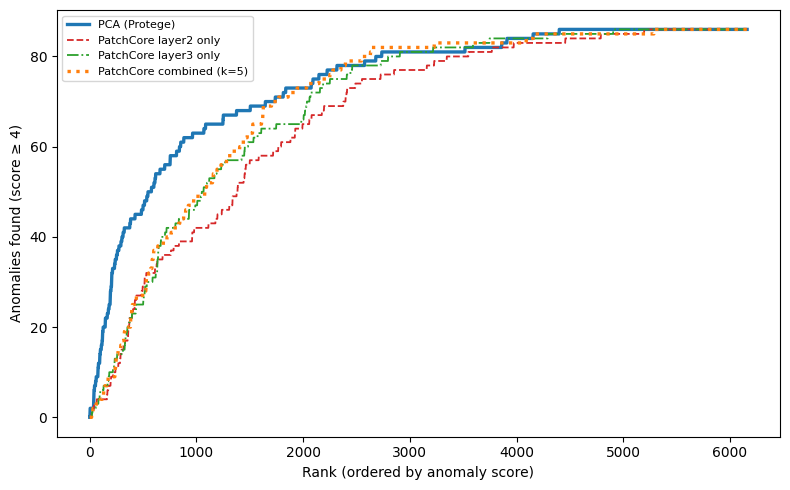

In [18]:
discovery_plot(
    ablation_methods,
    y_pc,
    highlight=['PCA (Protege)', f'PatchCore combined (k={best_k})']
)


## 14. Final Comparison — Protege vs Top-3 Methods

Compute ROC-AUC for every PatchCore variant,
pick the top-3 (excluding Protege), and plot alongside the baseline.


In [19]:
all_pc_methods = {
    'PCA (Protege)':            pca_scores_pc,
    f'PatchCore k=1':           k_scores[1],
    f'PatchCore k=3':           k_scores[3],
    f'PatchCore k=5':           k_scores[5],
    f'PatchCore k=10':          k_scores[10],
    'PatchCore layer2 only':    s_l2,
    'PatchCore layer3 only':    s_l3,
}

# ROC-AUC for every method
all_aucs = {
    name: compute_metrics(y_pc, s)['roc_auc']
    for name, s in all_pc_methods.items()
}

# Top-3 excluding Protege
ranked = sorted(
    {k: v for k, v in all_aucs.items() if k != 'PCA (Protege)'}.items(),
    key=lambda x: x[1], reverse=True
)
top3_names = [n for n, _ in ranked[:3]]

print('Top-3 PatchCore variants (by ROC-AUC):')
for n, auc in ranked[:3]:
    print(f'  {n}: {auc:.4f}')

# Final plot dict
final_methods = {'PCA (Protege)': pca_scores_pc}
for n in top3_names:
    final_methods[n] = all_pc_methods[n]

# Eval table
df_final = show_results(final_methods, y_pc, labels_pc)


Top-3 PatchCore variants (by ROC-AUC):
  PatchCore k=5: 0.8257
  PatchCore k=10: 0.8256
  PatchCore k=3: 0.8239


,ROC-AUC (4-5),PR-AUC (4-5),Recall@100 (4-5),Spearman (1-5)
Method,,,,
PCA (Protege),0.8674,0.1052,0.1744,0.0174
PatchCore k=5,0.8257,0.0476,0.0465,0.0066
PatchCore k=10,0.8256,0.0490,0.0349,0.0059
PatchCore k=3,0.8239,0.0480,0.0465,0.0069


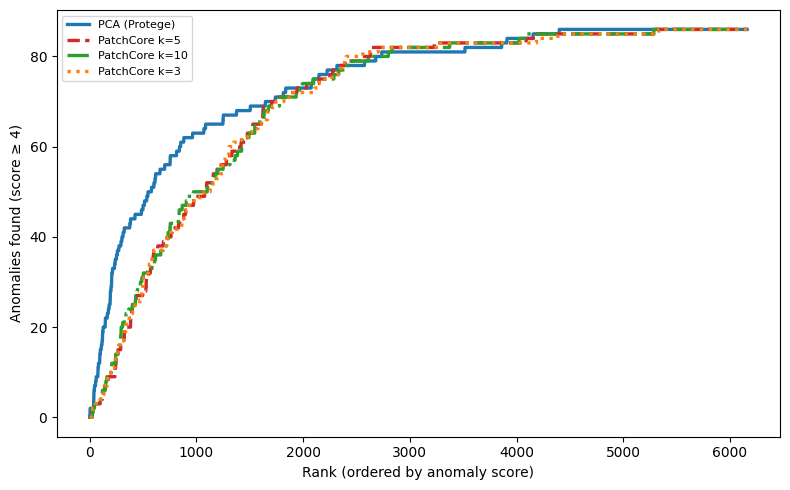

In [20]:
# Final discovery curve
discovery_plot(
    final_methods,
    y_pc,
    highlight=['PCA (Protege)'] + top3_names
)


## 15. How to Read These Results

### The key comparison
The gap between the **PCA (Protege)** curve and the **best PatchCore** curve
is the cost of working without human labels.

Protege uses active learning with real human feedback.
PatchCore is fully unsupervised — it has never seen a label.
The smaller the gap, the better our unsupervised approach.

### What the ablation tells you

| Result | Interpretation |
|---|---|
| Combined > layer2 and layer3 alone | Multi-scale representation helps — both layers contribute complementary information |
| Layer3 > layer2 | Semantic content (what the source is) is more useful than local texture for this dataset |
| Layer2 > layer3 | Local morphology (how the source looks spatially) drives anomaly detection |
| Combined ≈ layer3 alone | The 256 layer2 dimensions add noise rather than signal |

### What the k sweep tells you

| Best k | Interpretation |
|---|---|
| k=1 | Single nearest neighbour is sufficient — anomalies are clearly isolated |
| k=3 or k=5 | Averaging over a small neighbourhood helps — a few noisy neighbours exist |
| k=10 | Larger neighbourhood needed — feature space is noisy or high-dimensional effects present |

### Next step
The anomalib library implements PatchCore with proper multi-layer extraction
from multiple backbone options (ResNet18, WideResNet50, EfficientNet) and
includes patch-level (not just image-level) aggregation — closer to the
original paper's intent for detecting local anomalies in images.


---
## 16. Decomposition: How Much is PatchCore vs k-NN?

The final anomaly score is the product of **two distinct components**:

| Component | Role | What it does |
|---|---|---|
| **PatchCore** (feature extractor) | *Representation* | Transforms raw pixels into a multi-scale 768-dim embedding. Determines *what* the distance is measured on. |
| **k-NN** (anomaly scorer) | *Scoring* | Measures distance from each object to its nearest neighbours. Determines *how* anomalousness is computed. |

To isolate each component's contribution we run a **2×2 ablation**:

1. **PatchCore features + k-NN scoring** — the full system (baseline)
2. **BYOL features + k-NN scoring** — same scorer, weaker features
3. **PatchCore features + simple scoring** (mean distance to centroid) — better features, naive scorer
4. **BYOL features + simple scoring** — both components degraded

The performance gaps reveal whether the gains come from **richer features**, **better scoring**, or both.

In [1]:
# ── 16.1  Component-isolation helpers ────────────────────────────────────

from sklearn.metrics import roc_auc_score, average_precision_score


def centroid_scores(features: np.ndarray, index) -> pd.Series:
    """
    Simple baseline scorer: distance of each object to the feature-space
    centroid (mean of all objects).  No k-NN at all — pure geometry.
    """
    centroid = features.mean(axis=0, keepdims=True)
    dists    = np.linalg.norm(features - centroid, axis=1)
    return pd.Series(dists, index=index, name='score')


def knn_scores_np(query: np.ndarray, memory: np.ndarray,
                  k: int = 3) -> np.ndarray:
    """Re-usable k-NN scorer (duplicate-safe, works on any feature matrix)."""
    N      = len(query)
    scores = np.empty(N)
    done   = 0
    for chunk in pairwise_distances_chunked(
            query, memory, metric='euclidean',
            n_jobs=-1, working_memory=256):
        n_c      = chunk.shape[0]
        k_actual = min(k, chunk.shape[1])
        topk     = np.partition(chunk, k_actual - 1, axis=1)[:, :k_actual]
        scores[done:done + n_c] = topk.mean(axis=1)
        done += n_c
    return scores


# ── BYOL features (already loaded as X_byol) — restrict to same eval_ids ──
X_byol_eval  = X_byol.loc[eval_ids].values
X_byol_white = StandardScaler().fit_transform(X_byol_eval)

# ── 2×2 grid ──────────────────────────────────────────────────────────────
print('Running 2×2 component ablation...')

# (A) PatchCore features  +  k-NN scoring  ←  full system
s_pc_knn  = patchcore_scores                          # already computed

# (B) BYOL features  +  k-NN scoring
raw_byol_knn = knn_scores_np(X_byol_white, X_byol_white, k=best_k)
s_byol_knn   = pd.Series(raw_byol_knn, index=eval_ids, name='score')

# (C) PatchCore features  +  centroid scoring  (no k-NN)
s_pc_centroid   = centroid_scores(X_pc_whitened, eval_ids)

# (D) BYOL features  +  centroid scoring
s_byol_centroid = centroid_scores(X_byol_white, eval_ids)

component_methods = {
    'PCA (Protege)':                     pca_scores_pc,
    'A: PatchCore feats + k-NN':         s_pc_knn,
    'B: BYOL feats + k-NN':              s_byol_knn,
    'C: PatchCore feats + centroid':     s_pc_centroid,
    'D: BYOL feats + centroid':          s_byol_centroid,
}

df_components = show_results(component_methods, y_pc, labels_pc)
print('\nDone.')

NameError: name 'np' is not defined

In [ ]:
# ── 16.2  Quantify the contribution of each component ────────────────────
#
#  Feature contribution  = ROC-AUC(A) – ROC-AUC(B)   [same scorer, better feats]
#  k-NN contribution     = ROC-AUC(A) – ROC-AUC(C)   [same feats, better scorer]
#  Interaction           = (A – D) – feature_gain – knn_gain
#                          (synergy or redundancy between the two components)

def auc(s):
    return round(roc_auc_score(y_pc, s), 4)

auc_A = auc(s_pc_knn)
auc_B = auc(s_byol_knn)
auc_C = auc(s_pc_centroid)
auc_D = auc(s_byol_centroid)

feature_gain     = round(auc_A - auc_B, 4)   # PatchCore feats vs BYOL feats
knn_gain         = round(auc_A - auc_C, 4)   # k-NN scorer vs centroid scorer
total_gain       = round(auc_A - auc_D, 4)   # full system vs both degraded
interaction      = round(total_gain - feature_gain - knn_gain, 4)

# Express as % of total gain
if total_gain != 0:
    feat_pct  = round(100 * feature_gain / total_gain, 1)
    knn_pct   = round(100 * knn_gain     / total_gain, 1)
    inter_pct = round(100 * interaction  / total_gain, 1)
else:
    feat_pct = knn_pct = inter_pct = 0.0

print('━' * 60)
print('COMPONENT CONTRIBUTION ANALYSIS')
print('━' * 60)
print(f'  Baseline (D: BYOL + centroid)   ROC-AUC = {auc_D}')
print(f'  Full system (A: PC + k-NN)      ROC-AUC = {auc_A}')
print(f'  Total gain over baseline                = {total_gain:+.4f}')
print()
print(f'  PatchCore feature gain   (A–B)  = {feature_gain:+.4f}  ({feat_pct:+.1f}% of total)')
print(f'  k-NN scoring gain        (A–C)  = {knn_gain:+.4f}  ({knn_pct:+.1f}% of total)')
print(f'  Interaction (synergy)           = {interaction:+.4f}  ({inter_pct:+.1f}% of total)')
print('━' * 60)
print()

dominant = 'PatchCore features' if feature_gain >= knn_gain else 'k-NN scoring'
print(f'  ➜ The dominant contributor is: {dominant}')
if abs(interaction) > 0.005:
    direction = 'synergy (components amplify each other)' if interaction > 0 \
                else 'redundancy (components overlap)'
    print(f'  ➜ Interaction effect: {direction} ({interaction:+.4f})')

In [ ]:
# ── 16.3  Visualise the 2×2 grid ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: grouped bar chart (ROC-AUC by component choice) ─────────────────
ax = axes[0]
labels_bar  = ['BYOL features', 'PatchCore features']
centroid_auc = [auc_D, auc_C]
knn_auc      = [auc_B, auc_A]

x     = np.arange(len(labels_bar))
width = 0.32

bars1 = ax.bar(x - width/2, centroid_auc, width,
               label='Centroid scorer', color='#aec7e8', edgecolor='k', linewidth=0.6)
bars2 = ax.bar(x + width/2, knn_auc,     width,
               label='k-NN scorer',     color='#1f77b4', edgecolor='k', linewidth=0.6)

# Annotate bars
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., h + 0.002,
            f'{h:.4f}', ha='center', va='bottom', fontsize=8)

# Protege reference line
protege_auc = auc(pca_scores_pc)
ax.axhline(protege_auc, color='#d62728', linestyle='--', linewidth=1.3,
           label=f'Protege baseline ({protege_auc:.4f})')

ax.set_xticks(x)
ax.set_xticklabels(labels_bar)
ax.set_ylabel('ROC-AUC')
ax.set_title('ROC-AUC by Feature × Scorer choice')
ax.legend(fontsize=8)
y_min = min(auc_D, auc_C, auc_B, auc_A, protege_auc) - 0.02
y_max = max(auc_D, auc_C, auc_B, auc_A, protege_auc) + 0.04
ax.set_ylim(y_min, y_max)

# ── Right: stacked attribution bar (% of total gain) ──────────────────────
ax2 = axes[1]

portions    = [max(feat_pct,  0), max(knn_pct,  0), max(inter_pct,  0)]
neg_parts   = [min(feat_pct,  0), min(knn_pct,  0), min(inter_pct,  0)]
colors_pos  = ['#2ca02c', '#ff7f0e', '#9467bd']
bar_labels  = ['PatchCore features', 'k-NN scoring', 'Interaction']

bottom = 0.0
for val, neg, col, lbl in zip(portions, neg_parts, colors_pos, bar_labels):
    if val > 0:
        ax2.bar(0, val, bottom=bottom, color=col, edgecolor='k',
                linewidth=0.6, label=lbl)
        ax2.text(0, bottom + val / 2,
                 f'{lbl}\n{val:.1f}%',
                 ha='center', va='center', fontsize=9, color='white', fontweight='bold')
        bottom += val
    if neg < 0:   # draw negative portion below
        ax2.bar(0, neg, bottom=0, color=col, edgecolor='k',
                linewidth=0.6, alpha=0.5, label=f'{lbl} (negative)')

ax2.set_xlim(-0.6, 0.6)
ax2.set_xticks([])
ax2.set_ylabel('% of total ROC-AUC gain over baseline')
ax2.set_title('Attribution of ROC-AUC gain')
ax2.legend(fontsize=8, loc='lower right')
ax2.axhline(0, color='k', linewidth=0.8)

plt.suptitle(
    f'PatchCore vs k-NN Decomposition\n'
    f'Full system ROC-AUC = {auc_A:.4f}  |  '
    f'Baseline = {auc_D:.4f}  |  '
    f'Gain = {total_gain:+.4f}',
    fontsize=11
)
plt.tight_layout()
plt.show()